### School Discipline




In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv("./2021-22-crdc-data/SCH/Advanced Placement.csv", na_values=["", "NA", "null"])

print(df.head())

  LEA_STATE LEA_STATE_NAME   LEAID                LEA_NAME  SCHID  \
0        AL        ALABAMA  100002  Alabama Youth Services  99995   
1        AL        ALABAMA  100005        Albertville City    870   
2        AL        ALABAMA  100005        Albertville City    871   
3        AL        ALABAMA  100005        Albertville City    879   
4        AL        ALABAMA  100005        Albertville City    889   

                          SCH_NAME     COMBOKEY   JJ SCH_APSCIENR_IND  \
0                   AUTAUGA CAMPUS  10000299995  Yes               -9   
1        Albertville Middle School  10000500870   No               -9   
2          Albertville High School  10000500871   No              Yes   
3  Albertville Intermediate School  10000500879   No               -9   
4    Albertville Elementary School  10000500889   No               -9   

   SCH_APSCIENR_HI_M  ...  SCH_APMATHENR_WH_M  SCH_APMATHENR_WH_F  \
0                 -9  ...                  -9                  -9   
1       

/var/folders/y7/v0gq5f3n1dgdk22pyrvn0md00000gn/T/ipykernel_72293/1849115794.py:1: DtypeWarning: Columns (2,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("./2021-22-crdc-data/SCH/Advanced Placement.csv", na_values=["", "NA", "null"])


In [5]:
df = df.replace("-9", np.nan)
df = df.replace(-9, np.nan)

for c in df.columns:
    if c not in ["LEA_STATE","LEA_STATE_NAME","LEAID","LEA_NAME","SCHID","SCH_NAME","COMBOKEY","JJ",
                 "SCH_APSCIENR_IND","SCH_APCOMPENR_IND","SCH_APENR_IND","SCH_APMATHENR_IND"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

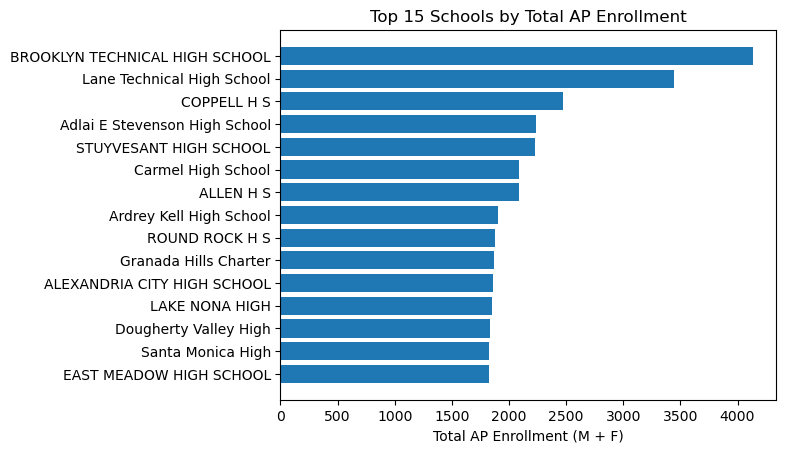

In [7]:
import matplotlib.pyplot as plt

df["TOT_APENR"] = df["TOT_APENR_M"].fillna(0) + df["TOT_APENR_F"].fillna(0)

top = df.sort_values("TOT_APENR", ascending=False).head(15)

plt.figure()
plt.barh(top["SCH_NAME"], top["TOT_APENR"])
plt.gca().invert_yaxis()
plt.title("Top 15 Schools by Total AP Enrollment")
plt.xlabel("Total AP Enrollment (M + F)")
plt.show()

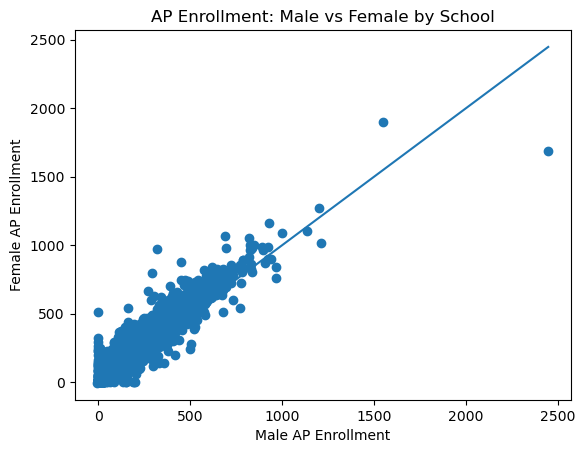

In [ ]:
x = df["TOT_APENR_M"]
y = df["TOT_APENR_F"]

plt.figure()
plt.scatter(x, y)
m = max(x.max(skipna=True), y.max(skipna=True))
plt.plot([0, m], [0, m])
plt.title("AP Enrollment: Male vs Female by School")
plt.xlabel("Male AP Enrollment")
plt.ylabel("Female AP Enrollment")
plt.show()


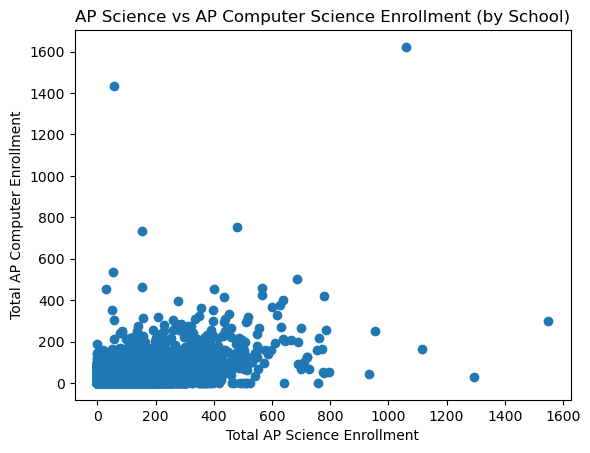

In [ ]:
df["TOT_APSCIENR"] = df["TOT_APSCIENR_M"].fillna(0) + df["TOT_APSCIENR_F"].fillna(0)
df["TOT_APCOMPENR"] = df["TOT_APCOMPENR_M"].fillna(0) + df["TOT_APCOMPENR_F"].fillna(0)

plt.figure()
plt.scatter(df["TOT_APSCIENR"], df["TOT_APCOMPENR"])
plt.title("AP Science vs AP Computer Science Enrollment (by School)")
plt.xlabel("Total AP Science Enrollment")
plt.ylabel("Total AP Computer Science Enrollment")
plt.show()
